В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [74]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from typing import Tuple
from xgboost import XGBClassifier
from sklearn.metrics import auc, roc_curve
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

In [2]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
# Read dataset from a file
raw_df = pd.read_csv('train.csv')

In [4]:
# Split into train and validation and then into inputs and targets
input_cols = raw_df.columns.drop(['id', 'CustomerId', 'Exited'])
target_col = 'Exited'

train_df, val_df = split_train_val(
    df=raw_df,
    target_col=target_col
)

X_train, y_train = separate_inputs_targets(
    df=train_df,
    input_cols=input_cols,
    target_col=target_col
)
X_val, y_val = separate_inputs_targets(
    df=val_df,
    input_cols=input_cols,
    target_col=target_col
)

1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [18]:
# Transform categorial featues to 'category' type
cat_features = X_train.select_dtypes(include=['object', 'category']).columns
X_train[cat_features] = X_train[cat_features].astype('category')
X_val[cat_features] = X_val[cat_features].astype('category')

# Make sure validation set has the same categories
for cat in cat_features:
    X_val[cat] = X_val[cat].cat.set_categories(
        X_train[cat].cat.categories
    )

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [19]:
# Create function to calculate AUROC
def get_auroc(target, probs):
    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])
    auroc = auc(fpr, tpr)

    return auroc

In [21]:
# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    enable_categorical=True,
    missing=np.nan,
    max_depth=5,
    n_estimators=20,
    random_state=333,
    eval_metric=auc
)

# Fit and predict probabilities
xgb_model.fit(X_train, y_train)
probs_train = xgb_model.predict_proba(X_train)
probs_val = xgb_model.predict_proba(X_val)

# Calculate and show AUROC
print('AUROC Train:', get_auroc(y_train, probs_train))
print('AUROC Val:', get_auroc(y_val, probs_val))

AUROC Train: 0.970335705505197
AUROC Val: 0.9328767405171823


**Висновок.** Дана модель показала хороші результати. На трейні вони кращі, тому тут присутній деякий high variance. І все ж результати на Валідейшні суттєво кращі, ніж у попередніх завданнях на Decision Tree. Тому я б обрав цю модель.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [128]:
# Objective function for optimization
def objective(model, params):
    match model:
        case 'xgb':
            clf = XGBClassifier(
                max_depth=params['max_depth'],
                n_estimators=params['n_estimators'],
                learning_rate=params['learning_rate'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                gamma=params['gamma'],
                reg_alpha=params['reg_alpha'],
                reg_lambda=params['reg_lambda'],
                random_state=333,
                enable_categorical=True,
                missing=np.nan,
            )
            clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        case 'lgbm':
            clf = lgb.LGBMClassifier(
                n_estimators=params['n_estimators'],
                learning_rate=params['learning_rate'],
                min_child_samples=params['min_child_samples'],
                num_leaves=params['num_leaves'],
                min_split_gain=params['min_split_gain'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                reg_alpha=params['reg_alpha'],
                reg_lambda=params['reg_lambda'],
                random_state=7,
                verbose=-1
              )
            clf.fit(X_train, y_train, eval_set=[(X_val, y_val)])
        case _:
            raise ValueError("Undefined model. Available values are: 'xgb', 'lgbm'.")

    probas = clf.predict_proba(X_val)

    auroc = get_auroc(y_val, probas)

    return {'loss': -auroc, 'status': STATUS_OK}

In [136]:
# Hyperparameters space
param_space = {
    'max_depth': hp.uniformint('max_depth', 2, 15),
    'n_estimators': hp.uniformint('n_estimators', 20, 500),
    'learning_rate': hp.uniform('learning_rate', 0.05, 0.5),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [140]:
# Search for the best parameters
trials = Trials()
best_params = fmin(
    fn=lambda params: objective('xgb', params),
    space=param_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(2026)
)
best_params = space_eval(param_space, best_params)
best_params

100%|██████████| 20/20 [00:08<00:00,  2.36trial/s, best loss: -0.9378194663557171]


{'colsample_bytree': 0.7288041941276818,
 'gamma': 0.1309295878765649,
 'learning_rate': 0.11455933510211375,
 'max_depth': 4,
 'n_estimators': 169,
 'reg_alpha': 0.2819255368927708,
 'reg_lambda': 0.22936844323265893,
 'subsample': 0.5235865536667825}

In [141]:
# Create XGBClassifier with optimized parameters
final_clf = XGBClassifier(
    max_depth=best_params['max_depth'],
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    reg_alpha=best_params['reg_alpha'],
    reg_lambda=best_params['reg_lambda'],
    random_state=333,
    enable_categorical=True,
    missing=np.nan,
)

# Fit and predict
final_clf.fit(X_train, y_train)
probas_train = final_clf.predict_proba(X_train)
probas_val = final_clf.predict_proba(X_val)

# Calculate and show AUROC
print('AUROC Train:', get_auroc(y_train, probas_train))
print('AUROC Val:', get_auroc(y_val, probas_val))

AUROC Train: 0.9715914553485175
AUROC Val: 0.9378194663557171


**Висновок.** Дана модель показала трохи кращі результати, ніж у попередньому завданні - і на трейні, і на валідації. Але все ще присутнє невелике перевищення variance.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

**Примітка:** я не буду використовувати параметри `missing` i `cat_feature`, тому що `LightGBM` видає ворнінги про них. Виявилось, що параметра `missing` не існує і за замовчуванням і так використовується `np.nan`. А `cat_feature` не потрібен, бо колонки вже переформатовані в тип `Categorical` і классіфаєр детектить їх автоматично.

In [142]:
# Initialize LightGBM Classifier
lgb_clf = lgb.LGBMClassifier(
    max_depth=3,
    n_estimators=70,
    learning_rate=0.1,
    random_state=7,
    verbose=-1
)

# Fit and predict probabilities
lgb_clf.fit(X_train, y_train)
probs_train = lgb_clf.predict_proba(X_train)
probs_val = lgb_clf.predict_proba(X_val)

# Calculate and show AUROC
print('AUROC Train:', get_auroc(y_train, probs_train))
print('AUROC Val:', get_auroc(y_val, probs_val))

AUROC Train: 0.9557429369105452
AUROC Val: 0.9352290966458605


**Висновок.** Ця модель хороша, має високі показники як на трейні, так і на валідейшні. Її результати трохи гірші, ніж на оптимізованому XGBoost, але трохи краще, ніж на неоптимізованому. До того ж ця модель має меншу різницю в AUROC для трейн і валідейшн наборах, а отже варіанс тут зменшився порівняно з попередньою моделлю.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [132]:
# LGBM hyperparameters space
lgbm_space = {
    'n_estimators': hp.uniformint('n_estimators', 50, 200),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'min_child_samples': hp.uniformint('min_child_samples', 5, 40),
    'num_leaves': hp.uniformint('num_leaves', 20, 100),
    'min_split_gain': hp.uniform('min_split_gain', 0, 0.1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

In [133]:
# Search for the best parameters
trials = Trials()
best_lgbm = fmin(
    fn=lambda params: objective('lgbm', params),
    space=lgbm_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=trials,
    rstate=np.random.default_rng(101)
)
best_lgbm = space_eval(lgbm_space, best_lgbm)
best_lgbm

100%|██████████| 10/10 [00:11<00:00,  1.16s/trial, best loss: -0.9355504492763564]


{'colsample_bytree': 0.8350097506697113,
 'learning_rate': 0.02834880582333989,
 'min_child_samples': 15,
 'min_split_gain': 0.034716205982265325,
 'n_estimators': 165,
 'num_leaves': 96,
 'reg_alpha': 0.05920091141077166,
 'reg_lambda': 0.522403482814098,
 'subsample': 0.6275587375162341}

In [143]:
# Create LGBMClassifier with optimized parameters
final_lgb_clf = lgb.LGBMClassifier(
    n_estimators=best_lgbm['n_estimators'],
    learning_rate=best_lgbm['learning_rate'],
    min_child_samples=best_lgbm['min_child_samples'],
    num_leaves=best_lgbm['num_leaves'],
    min_split_gain=best_lgbm['min_split_gain'],
    subsample=best_lgbm['subsample'],
    colsample_bytree=best_lgbm['colsample_bytree'],
    reg_alpha=best_lgbm['reg_alpha'],
    reg_lambda=best_lgbm['reg_lambda'],
    random_state=7
)

# Fit and predict
final_lgb_clf.fit(X_train, y_train)
probas_train_lgb = final_lgb_clf.predict_proba(X_train)
probas_val_lgb = final_lgb_clf.predict_proba(X_val)

# Calculate and show AUROC
print('AUROC Train:', get_auroc(y_train, probas_train_lgb))
print('AUROC Val:', get_auroc(y_val, probas_val_lgb))

AUROC Train: 0.9913028076869885
AUROC Val: 0.9355504492763564


**Висновок.** Результат цієї моделі на валідаційному наборі практично такий самий, як і у моделі із завдання (4). Але результат на трейні тут вищий і вже майже досягає 1.0. Це може свідчити про значний оверфіт, тому я би не обирав цю модель.

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [135]:
# Read test data from a file
test_raw_df = pd.read_csv('test.csv')
test_raw_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [146]:
# Separate input features
X_test = test_raw_df[input_cols].copy()

# Transform categorical columns into 'category' type
X_test[cat_features] = X_test[cat_features].astype('category')

# Make sure test set has the same categories as train
for cat in cat_features:
    X_test[cat] = X_test[cat].cat.set_categories(
        X_train[cat].cat.categories
    )

# Calculate probabilities for test and put them into the dataframe
test_raw_df['Exited'] = lgb_clf.predict_proba(X_test)[:, 1]

# Read submission file
submission = pd.read_csv('sample_submission.csv')

# Copy results to submission data frame
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])
print(submission.head())

# Check for missed values
print(submission.info())

# Write submission into a file
submission.to_csv('submission_lgbm_boost_hw.csv', index=False)

      id    Exited
0  15000  0.043931
1  15001  0.032034
2  15002  0.040455
3  15003  0.611839
4  15004  0.041045
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10000 non-null  int64  
 1   Exited  10000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 156.4 KB
None


**Висновок.** Я обрав модель `LGBMClassifier`, для котрої я задав параметри вручну, тому що вона показала один із найкращих результатів. При цьому її значення `AUROC` на трейні і валідейшні виявились найближчими одне до одного.

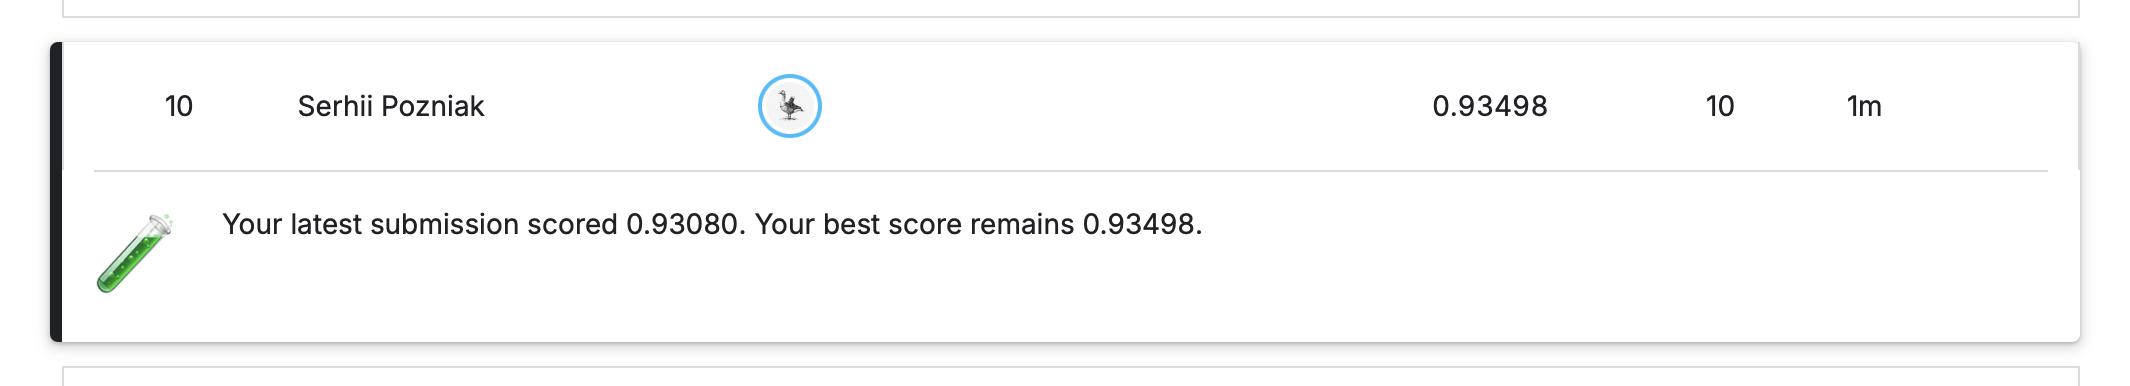

Поки найкращий результат я маю на Логістичній регресії. Думаю причиною є те, що залежності в цих даних не особливо складні, а алгоритм Логістичної регресії є детермінованим (не має великої кількості рандому). Також у цьому завданні ми провели замало раундів пошуку гіперпараметрів, можливо з більшою кількістю раундів можна буде отримати кращі результати.